**Overview**
- Numeric distributions: Look for skewness, outliers, or normality.
- Categorical vs loan_default: Identify categories with higher default rates.
- Correlation heatmap: Spot strong relationships (e.g., income vs loan amount).
- Missing values: Decide whether to impute, drop, or engineer features.

         age        income  credit_score   loan_amount  monthly_spend  \
0  43.960570  31019.390823    650.336822  33805.550343    1732.298149   
1  36.340828  39375.961557    648.261012  20974.755713    2334.610693   
2  45.772262  18055.668704    554.304978  26027.339787    1848.435993   
3  56.276358  15254.929250    656.893687  20798.610521    3256.259548   
4  35.190160  11486.292927    731.298036  14661.332950    7767.804367   

   experience_years employment_type education_level region risk_tolerance  \
0                13        salaried        bachelor   east           high   
1                32        salaried        bachelor  north           high   
2                 1        salaried        bachelor  south            low   
3                 1      unemployed          master   east            low   
4                30        salaried          master   west            low   

   financial_capacity_index  household_cashflow_score  behavior_score  \
0                 31.0193

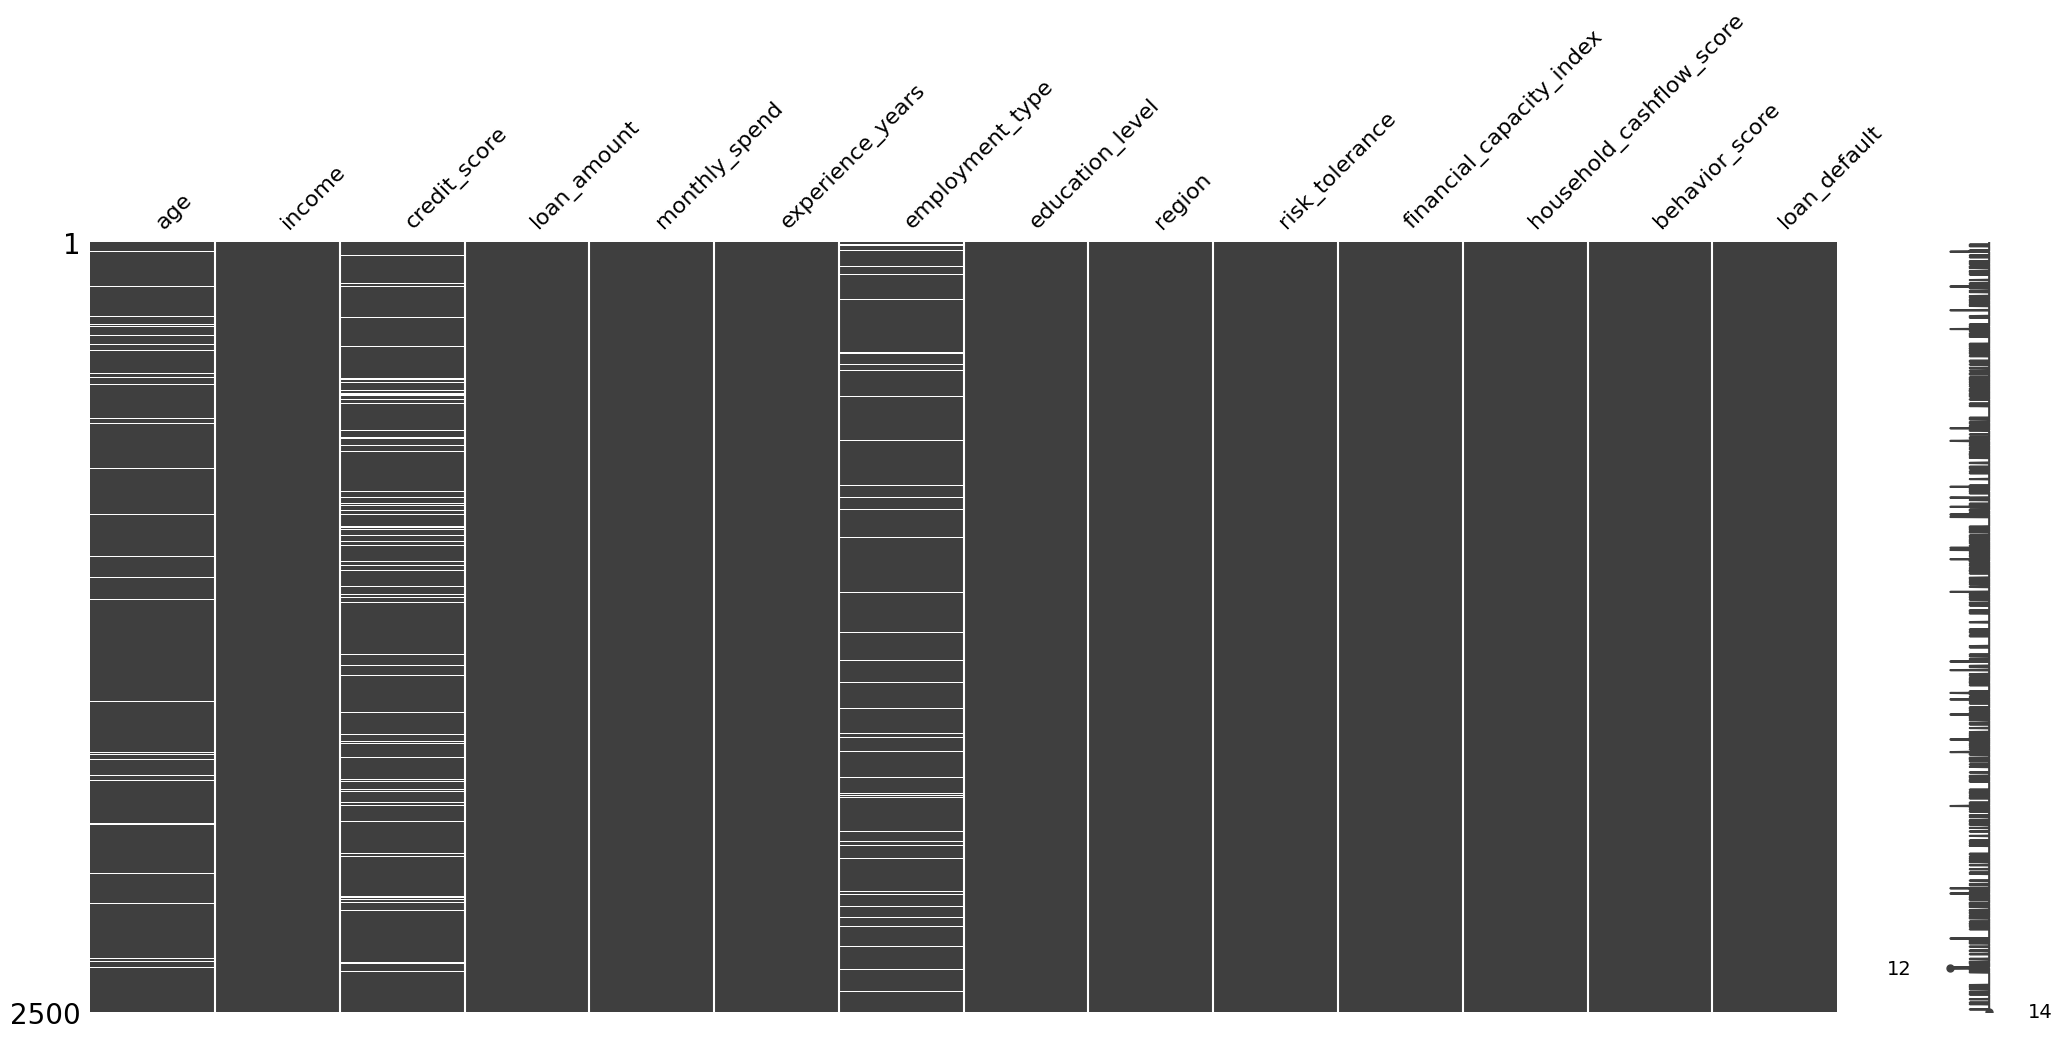

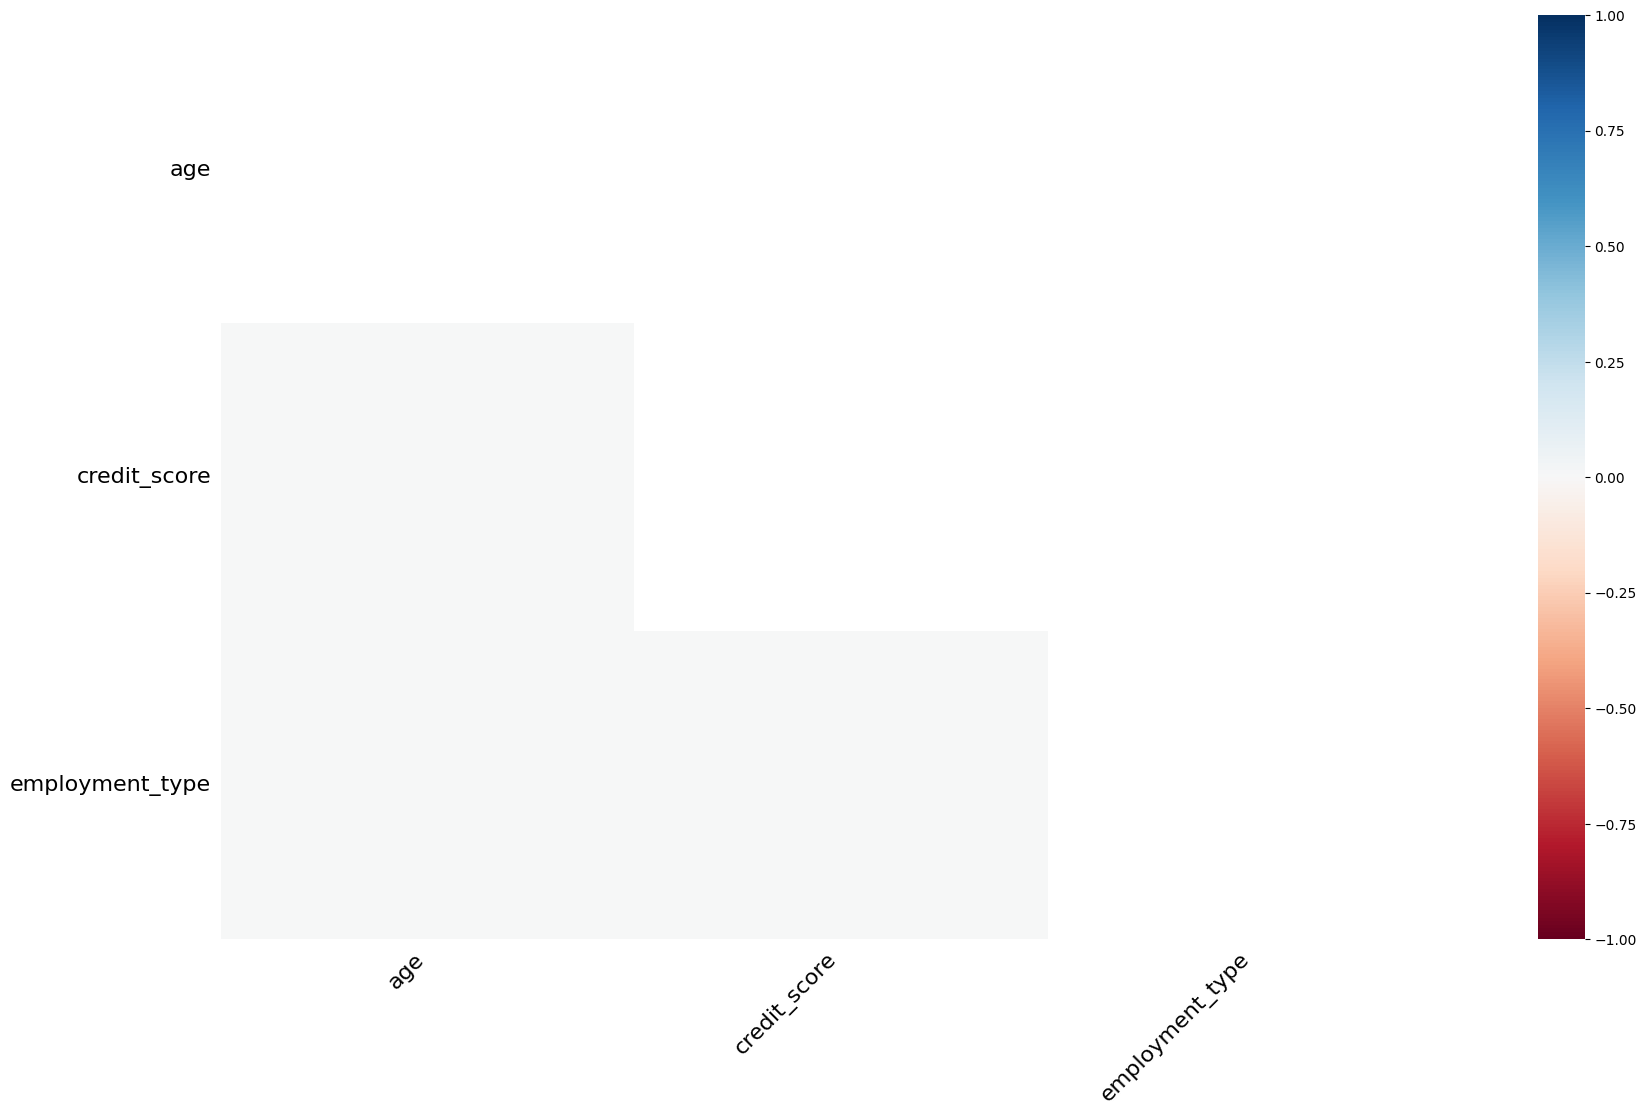

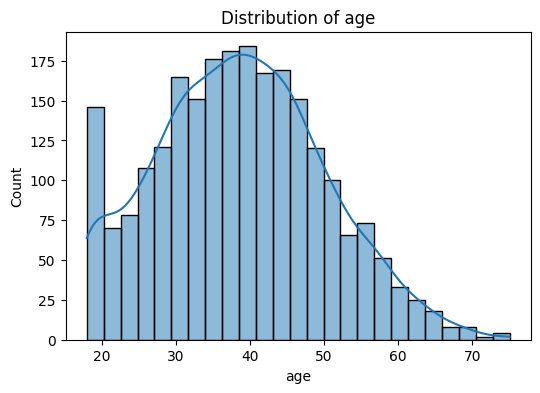

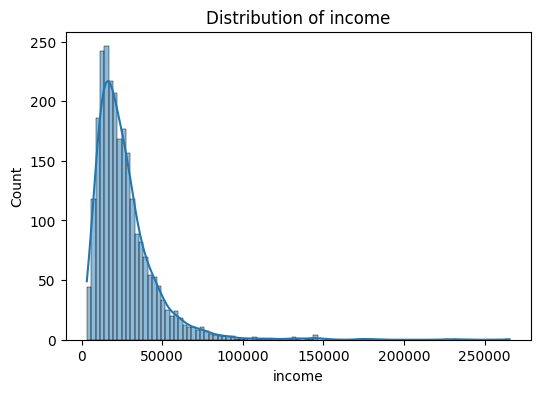

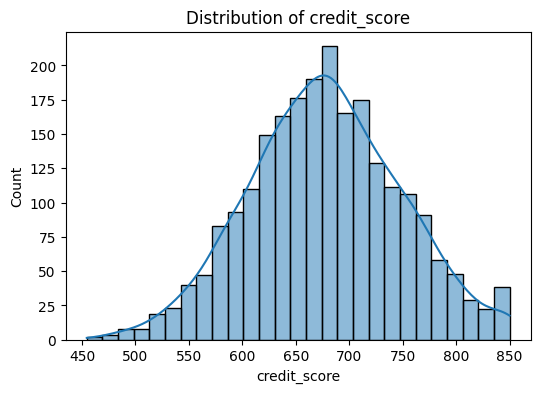

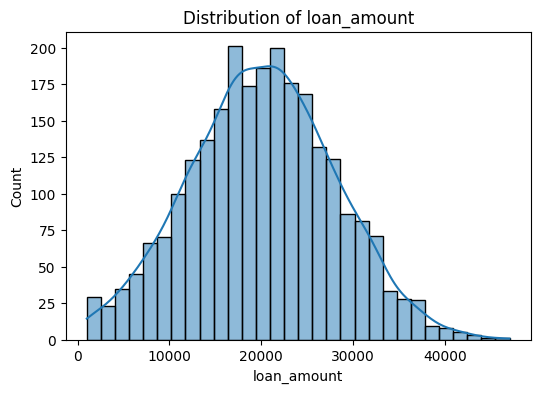

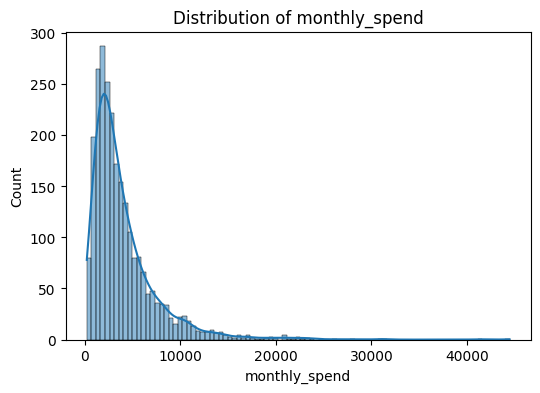

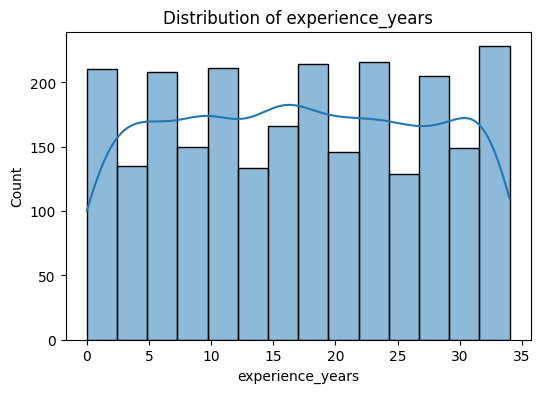

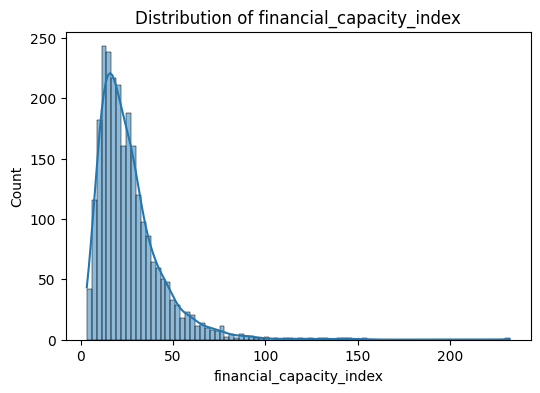

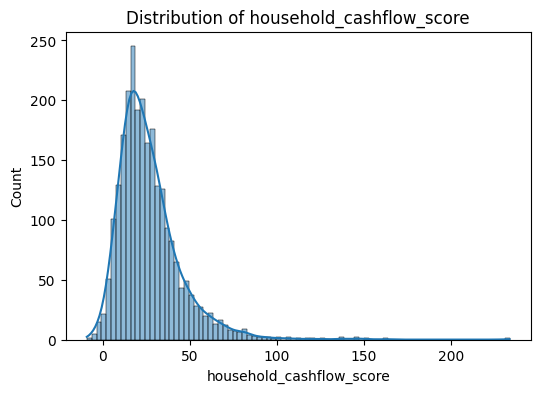

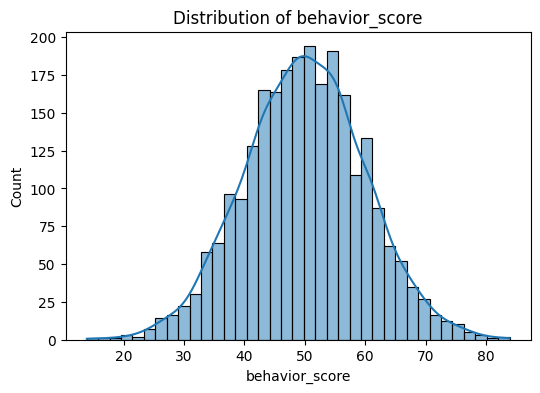

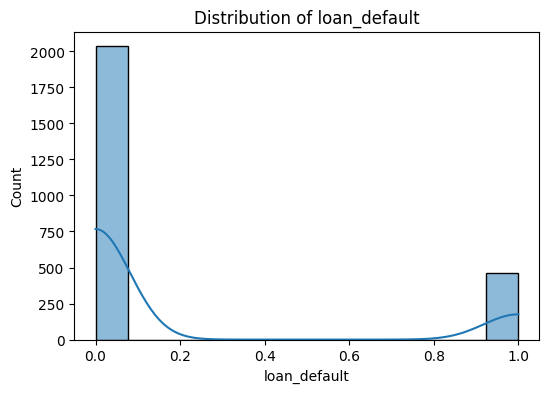

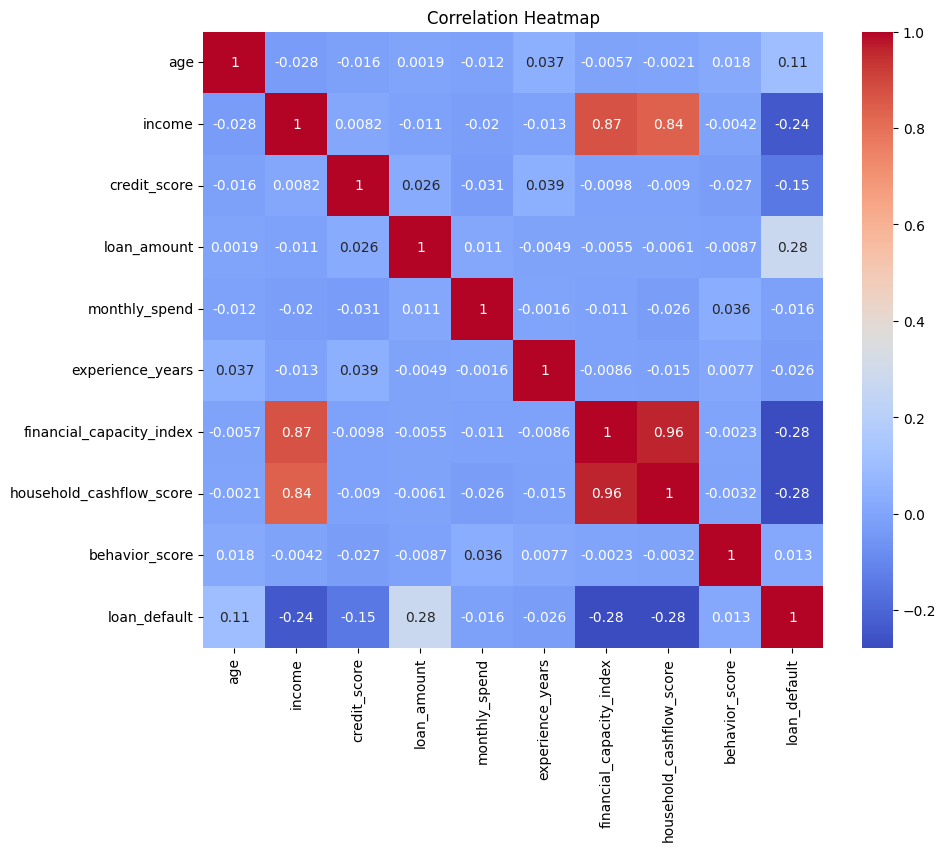

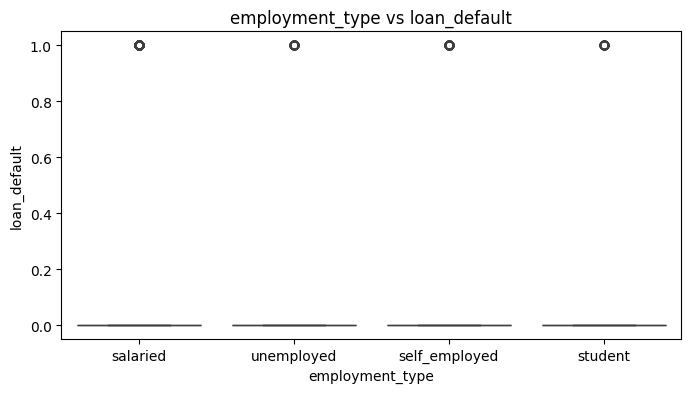

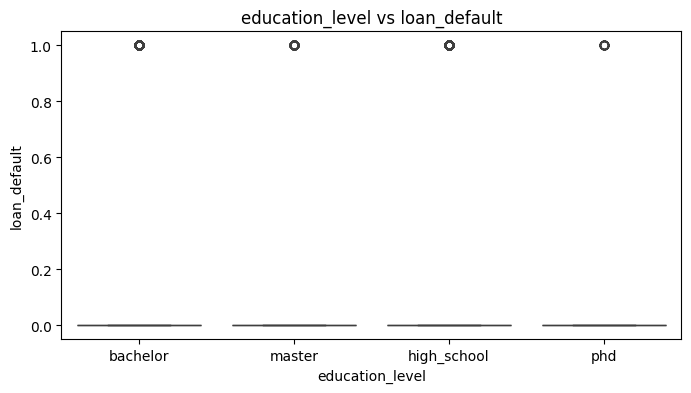

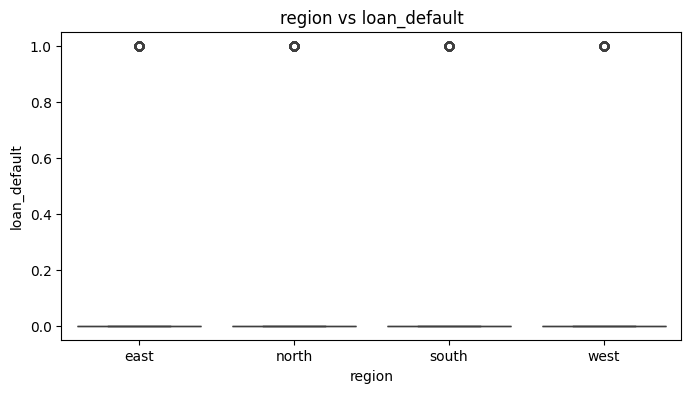

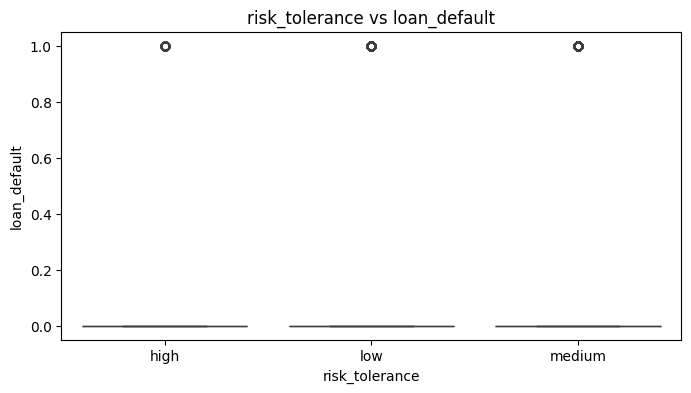

In [ ]:
import pandas as pd

url = "https://github.com/Sapphire-git/AssignmentDataset/raw/main/FeatureEngineeringDataset.xlsx"
df = pd.read_excel(url, engine="openpyxl")

print(df.head())
df.info()

#Identify Numerric and categorical features
# Numeric features
numeric_features = df.select_dtypes(include=['int64','float64']).columns
# Categorical features
categorical_features = df.select_dtypes(include=['object','category']).columns

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

# Summary Statistics
# For numeric features
df[numeric_features].describe()
# For categorical features
df[categorical_features].describe()

#Missing Values
import missingno as msno
# Count missing values
df.isnull().sum()
# Visualize missingness
msno.matrix(df)
msno.heatmap(df)

#Feature Distributions
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution plots for numeric features
for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
#Corelation Heatmap & Boxplot(Categorical vs Loan)
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

target = "loan_default"

for col in categorical_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y=target, data=df)
    plt.title(f"{col} vs {target}")
    plt.show()

**Output Summary**
- Financial variables (age, loan amount, behavior score) are the strongest predictors of loan default.
- Financial capacity index, household cashflow score have limited impact.
- Missing values need imputation strategies, especially for credit history.
- Log transformations may improve model performance due to skewness and outliers present.


age                125
credit_score       200
employment_type    125
dtype: int64


/tmp/ipykernel_1290/2773961792.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1290/2773961792.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

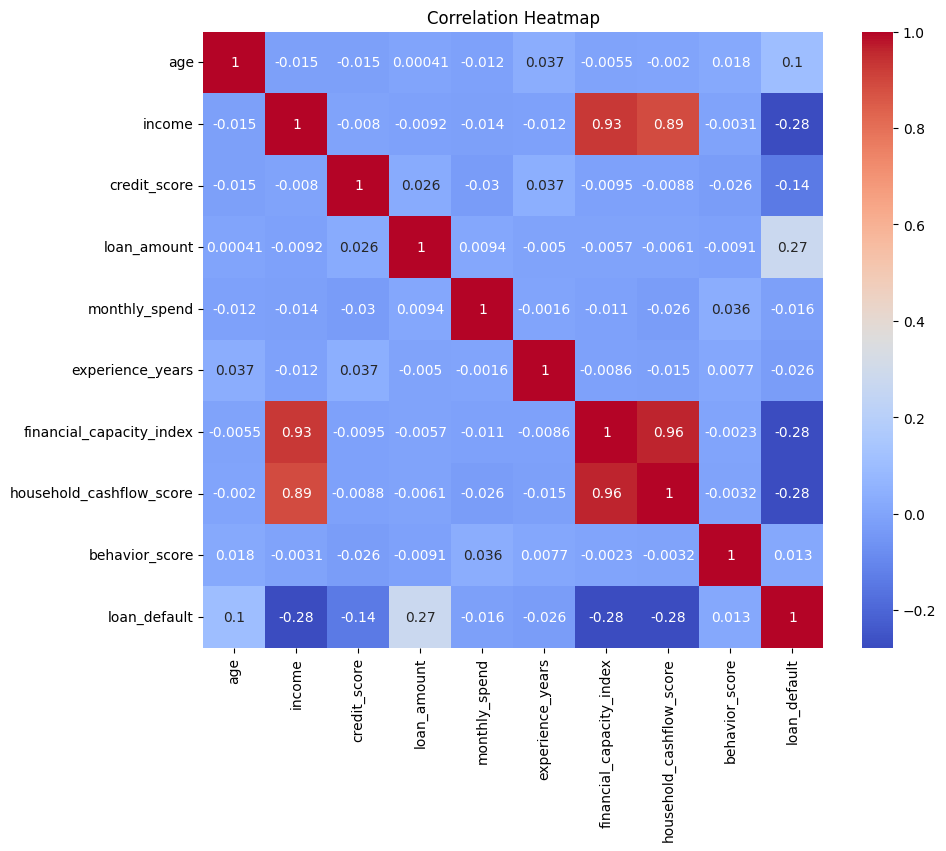

In [ ]:
import pandas as pd

url = "https://github.com/Sapphire-git/AssignmentDataset/raw/main/FeatureEngineeringDataset.xlsx"
df = pd.read_excel(url, engine="openpyxl")

#--------------------
#Missing values
#--------------------
missing_summary = df.isnull().sum()
print(missing_summary[missing_summary > 0])

#Handle missing values
# Numeric: median imputation
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical: mode imputation
for col in df.select_dtypes(include=['object','category']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

#--------------------
#Outlier Handling
#--------------------
import numpy as np

#Winsorization for loan amount and income
for col in ['loan_amount','income']:
    q_low = df[col].quantile(0.01)
    q_high = df[col].quantile(0.99)
    df[col] = np.where(df[col] < q_low, q_low, df[col])
    df[col] = np.where(df[col] > q_high, q_high, df[col])
#--------------------
#Redundant Variables
#--------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns before correlation
corr_matrix = df.select_dtypes(include=['float64','int64']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Drop highly correlated features (threshold > 0.9)
to_drop = [col for col in corr_matrix.columns
           if any(corr_matrix[col].abs() > 0.9) and col != 'loan_default']

df.drop(columns=to_drop, inplace=True)

**Explaining the feature choices**
- Imputation: Preserves dataset size and avoids bias from dropping rows. Median/mode choices are robust against skewness and imbalance.
- Outlier handling: Winsorization reduces distortion in model training while keeping most data intact. Robust scaling ensures models aren’t dominated by extreme values.
- Feature reduction: Dropping redundant variables improves interpretability, prevents overfitting, and enhances model stability

**Task 3 Numeric Feature Engineering**

In [ ]:
import pandas as pd

url = "https://github.com/Sapphire-git/AssignmentDataset/raw/main/FeatureEngineeringDataset.xlsx"
df = pd.read_excel(url, engine="openpyxl")
import numpy as np
#Log Transformation: Reduces skewness in financial variables, stabilizes variance, and makes distributions closer to normal.
# Ensuring numeric and non-negative before log transform
for col in ['loan_amount','income']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')   # convert to numeric
        df[col] = df[col].fillna(0)                         # replace NaNs with 0
        df[col] = np.where(df[col] < 0, 0, df[col])         # cap negatives at 0
        df[col] = np.log1p(df[col])                         # log(x+1)
    else:
        print(f"Column {col} not found in dataset")

#Standardization: Centers features around mean 0 with unit variance, improving performance for models sensitive to scale (e.g., logistic regression, SVM).
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

#Discretization: Converts continuous variables into categorical bins, capturing non‑linear relationships (e.g., default risk varying by age group).
# Example: binning age into categories
df['age_bin'] = pd.cut(df['age'], bins=[18,30,40,50,60,100],
                       labels=['18-30','31-40','41-50','51-60','60+'])

**Task 4 Feature Construction**

- Ratio Feature captures the applicant’s financial burden relative to their income. A higher ratio indicates higher risk of default, making it a strong predictive feature.
- Interaction Feature Combining credit score with loan amount highlights how risk changes when large loans are taken by applicants with varying credit scores. This interaction can reveal non‑linear effects missed by individual features
- Polynomial Feature captures non‑linear relationships. For example, very high incomes may reduce default probability disproportionately compared to moderate incomes.

In [ ]:
import pandas as pd

url = "https://github.com/Sapphire-git/AssignmentDataset/raw/main/FeatureEngineeringDataset.xlsx"
df = pd.read_excel(url, engine="openpyxl")
# Ratio Feature
# Debt-to-Income Ratio
df['debt_income_ratio'] = df['loan_amount'] / (df['income'] + 1)

# Interaction Feature
# Interaction between Credit Score and Loan Amount
df['credit_loan_interaction'] = df['credit_score'] * df['loan_amount']

# Polynomial Feature
# Square of Applicant Income
df['income_squared'] = df['income'] ** 2

**Task 5 — Categorical Feature Encoding**

One Hot Encoding
- These features have only a few categories (e.g., education_level, Region, employment_type).
- It avoids false numeric ordering and makes them usable in linear models.

Label Encoding
- Employment type and dependents may have more categories.
- Label Encoding is efficient and works well with tree‑based models (Random Forest, XGBoost) that don’t assume linearity.
- For ordinal features (like dependents: 0,1,2,3+), label encoding preserves natural order.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

url = "https://github.com/Sapphire-git/AssignmentDataset/raw/main/FeatureEngineeringDataset.xlsx"
df = pd.read_excel(url, engine="openpyxl")
# Identify categorical columns
categorical_cols = ['employment_type', 'education_level', 'region', 'risk_tolerance']

# OneHotEncoding
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[categorical_cols])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

# Merge back into dataset
df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)

In [ ]:
import pandas as pd

url = "https://github.com/Sapphire-git/AssignmentDataset/raw/main/FeatureEngineeringDataset.xlsx"
df = pd.read_excel(url, engine="openpyxl")
# Label Encoding
from sklearn.preprocessing import LabelEncoder
high_cardinality = ['employment_type','education_level']

for col in high_cardinality:
    le = LabelEncoder()
    df[col+'encoded'] = le.fit_transform(df[col])
    df.drop(columns=[col], inplace=True)

**Task 6 — Feature Selection**

In [ ]:
import pandas as pd
url = "https://github.com/Sapphire-git/AssignmentDataset/raw/main/FeatureEngineeringDataset.xlsx"
df = pd.read_excel(url, engine="openpyxl")

#Pearson Correlation
# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64','int64'])

# Correlation with target
corr = numeric_df.corr()['loan_default'].sort_values(ascending=False)
print(corr)

# Mutual Information
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Ensure target is numeric
y = df['loan_default']
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y.astype(str))

# Encode categorical features
X = df.drop(columns=['loan_default']).copy()
for col in X.select_dtypes(include=['object','category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Force all columns to numeric
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Final check
print(X.dtypes)

# Mutual Information
mi_scores = mutual_info_classif(X, y, discrete_features='auto', random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print(mi_series)

loan_default                1.000000
loan_amount                 0.275734
age                         0.106593
behavior_score              0.012528
monthly_spend              -0.016051
experience_years           -0.026328
credit_score               -0.146262
income                     -0.242271
household_cashflow_score   -0.275211
financial_capacity_index   -0.277489
Name: loan_default, dtype: float64
age                         float64
income                      float64
credit_score                float64
loan_amount                 float64
monthly_spend               float64
experience_years              int64
employment_type               int64
education_level               int64
region                        int64
risk_tolerance                int64
financial_capacity_index    float64
household_cashflow_score    float64
behavior_score              float64
dtype: object
financial_capacity_index    0.076257
income                      0.074727
household_cashflow_score    0.064447
lo

  **Findings**
- The most predictive features are financial and behavioral: loan amount, income, credit score, behavior score.
- Redundant features (financial capacity index and household cashflow score) should be reduced to avoid multicollinearity.
- Lowest impact features (age, experience, region) can be dropped or deprioritized, as they add little predictive value.

**Task 7 — Multicollinearity Analysis**
Highly Correlated Pairs
- Financial Capacity Index ↔ Household Cashflow Score (≈ 0.96)(Extremely strong correlation, almost identical information).
- Financial Capacity Index ↔ Income (≈ 0.87)(High correlation, since the index is partly derived from income).
- Household Cashflow Score ↔ Income (≈ 0.84)(Strong correlation, both reflect financial strength)


**Task 8 — Dimensionality Reduction**
PCA Technique Used
- Interpretability: PCA is widely used and easy to explain — it transforms correlated features into independent components.
- Redundancy removal: Your dataset has highly correlated features (e.g., financial capacity index ↔ household cashflow score). PCA helps compress them into fewer dimensions.
- Scalability: Works well with numeric features and large datasets, unlike t‑SNE which is mainly for visualization.


In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Load dataset
url = "https://github.com/Sapphire-git/AssignmentDataset/raw/main/FeatureEngineeringDataset.xlsx"
df = pd.read_excel(url, engine="openpyxl")

# Separate target
y = df['loan_default']
X = df.drop(columns=['loan_default']).copy()

# Encode categorical features
for col in X.select_dtypes(include=['object','category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Handle missing values (replace NaN with column mean)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Standardize features
X_scaled = StandardScaler().fit_transform(X_imputed)

# Apply PCA
pca = PCA(n_components=None)  # keep all initially
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_variance)

# Cumulative variance to decide components
cumulative_variance = explained_variance.cumsum()
print("Cumulative variance:", cumulative_variance)

Explained variance ratio: [0.21434019 0.0863235  0.08292798 0.08023619 0.07974675 0.07801741
 0.07621537 0.07384308 0.07268996 0.07082047 0.06835962 0.01379644
 0.00268304]
Cumulative variance: [0.21434019 0.30066369 0.38359167 0.46382786 0.54357461 0.62159202
 0.69780738 0.77165046 0.84434042 0.9151609  0.98352052 0.99731696
 1.        ]


**Final Summary**
- Technique chosen: PCA, because it reduces redundancy and is interpretable.
- Components retained: 10, explaining ~91.5% of the dataset’s variance.
- Information preserved: Core financial and behavioral signals that drive loan default risk.
- Information discarded: Minor demographic variations and noise that contribute little predictive value.